Cargo los datos

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [2]:
# Load CSV using NumPy
import csv
import numpy as np

filename = 'C:/Users/bea-j/Documents/UNIVERSIDAD/4.2 CUARTO/TFG/Pruebas Jupyter/Tx_8B'
#lectura binario
raw_data = open(filename, 'rb')
data = np.loadtxt(raw_data, delimiter = ',')
print(data)
print(data.shape)

[[-73. -76. -76. ... -88. -77.   1.]
 [-73. -82. -84. ... -81. -93.   1.]
 [-89. -82. -76. ... -82. -83.   1.]
 ...
 [-91. -80. -76. ... -91. -66.  21.]
 [-88. -89. -71. ... -86. -96.  21.]
 [-95. -97. -76. ... -82. -84.  21.]]
(2100, 7)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
filename = 'C:/Users/bea-j/Documents/UNIVERSIDAD/4.2 CUARTO/TFG/Pruebas Jupyter/Tx_8B'
names = ['Beacon1', 'Beacon2', 'Beacon3', 'Beacon4', 'Beacon5', 'Beacon6', 'Sector']
data = pd.read_csv(filename, names=names)
array = data.values
# separate array into input and output components
X = array[:,0:6] #Todas las filas (:), de columna 0 hasta 6
Y = array[:,6] #Todas las filas (:) y columna 6
print(X)

[[-73 -76 -76 -98 -88 -77]
 [-73 -82 -84 -99 -81 -93]
 [-89 -82 -76 -60 -82 -83]
 ...
 [-91 -80 -76 -73 -91 -66]
 [-88 -89 -71 -72 -86 -96]
 [-95 -97 -76 -77 -82 -84]]


C:\Users\bea-j\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\bea-j\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\bea-j\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-lev

<AxesSubplot:xlabel='RSSI', ylabel='Density'>

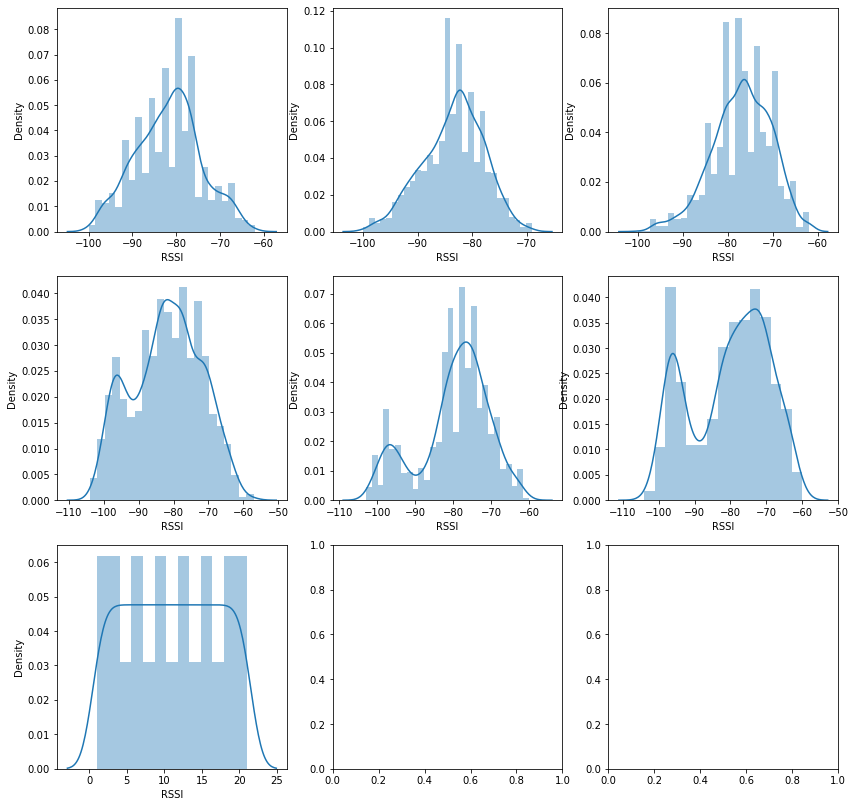

In [4]:
%matplotlib inline
# Univariate Histograms
import matplotlib.pyplot as ptl
import seaborn as sns
f, axes = ptl.subplots(3, 3, figsize = (14,14))
sns.distplot(data["Beacon1"], axlabel = "RSSI", ax = axes[0,0])
sns.distplot(data["Beacon2"], axlabel = "RSSI", ax = axes[0,1])
sns.distplot(data["Beacon3"], axlabel = "RSSI", ax = axes[0,2])
sns.distplot(data["Beacon4"], axlabel = "RSSI", ax = axes[1,0])
sns.distplot(data["Beacon5"], axlabel = "RSSI", ax = axes[1,1])
sns.distplot(data["Beacon6"], axlabel = "RSSI", ax = axes[1,2])
sns.distplot(data["Sector"], axlabel = "RSSI", ax = axes[2,0])

Transformación de datos con Yeo-Johnson

In [5]:
# Box-Cox Transform
from sklearn.preprocessing import PowerTransformer
# extract features with skew
features = data[['Beacon1', 'Beacon2', 'Beacon3', 'Beacon4', 'Beacon5', 'Beacon6']]
#instatiate 
pt = PowerTransformer(method='yeo-johnson', standardize=True)
#Fit the data to the powertransformer
skl_boxcox = pt.fit(features)
#Lets get the Lambdas that were found
#print (skl_boxcox.lambdas_)
calc_lambdas = skl_boxcox.lambdas_
#Transform the data 
skl_boxcox = pt.transform(features)
#Pass the transformed data into a new dataframe 
df_features = pd.DataFrame(data=skl_boxcox, columns=['Beacon1', 'Beacon2', 'Beacon3', 'Beacon4', 'Beacon5', 'Beacon6'])
# Pass to the original dataframe the transform columns
data.drop(['Beacon1'], axis=1, inplace=True)
data.drop(['Beacon2'], axis=1, inplace=True)
data.drop(['Beacon3'], axis=1, inplace=True)
data.drop(['Beacon4'], axis=1, inplace=True)
data.drop(['Beacon5'], axis=1, inplace=True)
data.drop(['Beacon6'], axis=1, inplace=True)
# Concatenar ambos dataframes
df_data = pd.concat([data, df_features], axis=1)
cols = df_data.columns.tolist()
# Pasa e útimo elemento al primero de la lista (2 veces)
cols = cols[-1:] + cols[:-1]
cols = cols[-1:] + cols[:-1]
cols = cols[-1:] + cols[:-1]
cols = cols[-1:] + cols[:-1]
cols = cols[-1:] + cols[:-1]
cols = cols[-1:] + cols[:-1]
# Sobreescrimos
df_data = df_data[cols]
df_data

,Beacon1,Beacon2,Beacon3,Beacon4,Beacon5,Beacon6,Sector
0,1.177179,1.399130,0.076146,-1.562970,-0.943346,0.212330,1
1,1.177179,0.210708,-1.085624,-1.655382,-0.264159,-1.144411,1
2,-0.973544,0.210708,0.076146,2.362640,-0.369702,-0.343954,1
3,0.102480,0.210708,-1.085624,-0.806919,-0.155458,-0.430622,1
4,0.371284,-0.152631,-0.671437,2.717437,-0.762744,-0.681280,1
...,...,...,...,...,...,...,...
2095,-1.512016,0.589705,0.235135,0.493289,-0.762744,-1.358928,21
2096,-1.108134,1.399130,-0.527894,0.082844,-1.114393,-1.217099,21
2097,-1.242743,0.589705,0.076146,0.913961,-1.196554,1.430042,21
2098,-0.838972,-0.998782,0.906449,1.020821,-0.762744,-1.358928,21


C:\Users\bea-j\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\bea-j\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\bea-j\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-lev

<Figure size 432x288 with 0 Axes>

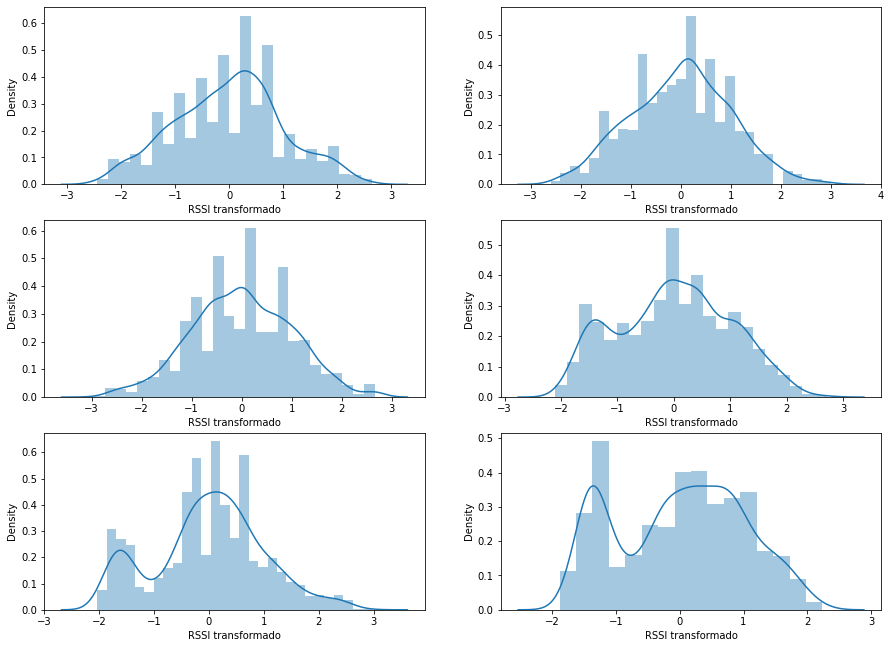

In [6]:
%matplotlib inline
# Univariate Histograms
plt.figure(1)
plt.subplots(figsize=(15,15))
plt.subplot(421)
sns.distplot(df_data['Beacon1'], axlabel = "RSSI transformado")
#plt.title('Beacon1')
#plt.grid(True)
plt.subplot(422)
sns.distplot(df_data['Beacon2'], axlabel = "RSSI transformado")
#plt.title('Beacon2')
#plt.grid(True)
plt.subplot(423)
sns.distplot(df_data['Beacon3'], axlabel = "RSSI transformado")
#plt.title('Beacon3')
#plt.grid(True)
plt.subplot(424)
sns.distplot(df_data['Beacon4'], axlabel = "RSSI transformado")
#plt.title('Beacon4')
#plt.grid(True)
plt.subplot(425)
sns.distplot(df_data['Beacon5'], axlabel = "RSSI transformado")
#plt.title('Beacon5')
#plt.grid(True)
plt.subplot(426)
sns.distplot(df_data['Beacon6'], axlabel = "RSSI transformado")
#plt.title('Beacon6')
#plt.grid(True)
plt.show()

Remuestreo de datos (pre-procesamiento)

k-fold cross validation

In [10]:
# Evaluate using Cross Validation
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

num_folds = 10
seed = 7
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
model = LogisticRegression(solver='lbfgs', max_iter=1000)
results = cross_val_score(model, X, Y, cv=kfold)
print(f"Accuracy: {results.mean()*100.0:,.2f}% ({results.std()*100.0:,.2f}%)")

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy: 32.05% (3.53%)


C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validación cruzada repetida

In [11]:
# Evaluate using Leave One Out Cross Validation
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

num_folds = 10
seed = 7
num_repeated = 5
repeatedkfold = RepeatedKFold(n_splits=num_folds, n_repeats=num_repeated, random_state=seed)
model = LogisticRegression(solver='lbfgs', max_iter=1000)
results = cross_val_score(model, X, Y, cv=repeatedkfold)
print(f"Accuracy: {results.mean()*100.0:,.2f}% ({results.std()*100.0:,.2f}%)")

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy: 32.09% (3.12%)


Validación cruzada dejando uno fuera

In [12]:
# Evaluate using Leave One Out Cross Validation
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

loocv = LeaveOneOut()
model = LogisticRegression(solver='lbfgs', max_iter=100)
results = cross_val_score(model, X, Y, cv=loocv)
print(f"Accuracy: {results.mean()*100.0:,.2f}% ({results.std()*100.0:,.2f}%)")

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

...

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 25.29% (43.46%)


C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


División por porcentaje

In [13]:
# Evaluate using a train and a test set
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

test_size = 0.33
seed = 7
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state = seed)
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, Y_train)
results = model.score(X_test, Y_test)
print(f"Accuracy: {results*100.0:,.2f}%")

Accuracy: 34.20%


C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


División por porcentaje repetidos aleatoriamente

In [14]:
# Evaluate using Shuffle Split Cross Validation
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

test_size = 0.33
seed = 7
n_splits = 10
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state = seed)
kfold = ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=seed)
model = LogisticRegression(solver='lbfgs', max_iter=1000)
results = cross_val_score(model, X, Y, cv=kfold)
print(f"Accuracy: {results.mean()*100.0:,.2f}% ({results.std()*100.0:,.2f}%)")

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy: 32.06% (1.46%)


C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluación de algoritmos

Accuracy

In [15]:
# Cross Validation Classification Accuracy (Porcentaje de acierto)

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

kfold = KFold(n_splits=10, random_state=7, shuffle=True)
model = LogisticRegression(solver='lbfgs', max_iter=1000)
scoring = 'accuracy'
results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
print(f"Accuracy: {results.mean()*100.0:,.2f}% ({results.std()*100.0:,.2f}%)")

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy: 32.05% (3.53%)


C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Kappa

In [16]:
# Cross Validation Classification Confusion Matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
from sklearn.linear_model import LogisticRegression

test_size=0.33
seed=7
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, Y_train)
predicted = model.predict(X_test)
cohen_score = cohen_kappa_score(Y_test, predicted)
print(f"Cohens score: {cohen_score*100.0:,.2f}%")

Cohens score: 30.89%


C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Matriz de confusión

In [7]:
# Cross Validation Classification Confusion Matrix
# Lo más importante para trabajas con problema de clasificación
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression

test_size=0.33
seed=7
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, Y_train)
predicted = model.predict(X_test)
matriz =confusion_matrix(Y_test, predicted)
print(matriz)

[[13  0  1  3  1  1  0  5  1  1  1  6  0  0  1  0  0  0  1  0  1]
 [ 0 18  0  0  4  0  0  1  0  0  0  0  0  4  1  0  0  1  1  0  1]
 [ 2  1 22  3  3  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  4  7 25  0  0  0  0  1  0  1  0  0  4  0  0  0  1  0  0  0]
 [ 0  3  2  0 23  3  0  0  2  0  0  0  1  1  0  0  0  2  0  0  0]
 [ 1  0  3  0  1 20  0  1  1  1  0  0  0  0  0  0  0  0  0  0  4]
 [ 0  1  0  0  1  2  3  1  3  0  4  3  0  4  0  0  2  2  3  0  4]
 [ 6  1  4  0  1  3  0  4  0  1  2  3  2  0  2  0  1  1  0  0  3]
 [ 2  1  1  2  1  1  0  2  3  0  3  0  0  6  0  0  1  1  2  2  3]
 [ 6  2  0  0  0  2  0  3  4  5  5  0  0  1  0  1  2  0  0  0  1]
 [ 1  1  0  0  1  0  0  0  4  0 10  0  0  4  2  0  2  3  1  2  2]
 [ 3  0  0  0  0  0  1  0  1  2  4 18  0  0  0  0  0  1  4  0  0]
 [ 0  0  0  0  1  2  0  0  0  1  2  3  4  0  0  2  3  0  6  4  4]
 [ 0  5  0  0  1  0  0  1  1  0  4  0  0 15  2  0  3  0  0  2  0]
 [ 1  7  0  0  0  4  0  2  1  2  0  0  3  0  2  0  3  0  1  2  6]
 [ 0  0  0

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Reporte de clasificación

In [18]:
# Cross Validation Classification Report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

test_size = 0.33
seed = 7
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, Y_train)
predicted = model.predict(X_test)
report = classification_report(Y_test, predicted) 
print(report)

              precision    recall  f1-score   support

           1       0.36      0.36      0.36        36
           2       0.39      0.58      0.47        31
           3       0.55      0.69      0.61        32
           4       0.76      0.58      0.66        43
           5       0.56      0.62      0.59        37
           6       0.43      0.62      0.51        32
           7       0.75      0.09      0.16        33
           8       0.20      0.12      0.15        34
           9       0.12      0.10      0.11        31
          10       0.26      0.16      0.20        32
          11       0.22      0.30      0.25        33
          12       0.41      0.53      0.46        34
          13       0.16      0.12      0.14        32
          14       0.31      0.44      0.37        34
          15       0.15      0.06      0.09        34
          16       0.24      0.16      0.19        31
          17       0.10      0.14      0.12        22
          18       0.14    

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Selección de características

Coeficiente de correlación

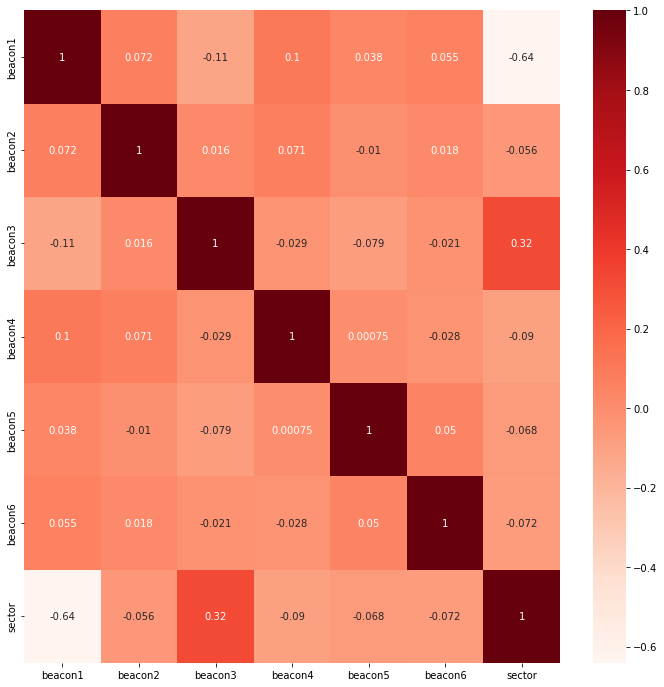

In [5]:
#Using Pearson Correlation
plt.figure(figsize=(12,12))
cor = data.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

Algoritmos de ML

Comparación de varios

In [19]:
# Compare Algorithms
# prepare models
models = []
models.append(('LoR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('k-NN', KNeighborsClassifier(n_neighbors=19)))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto'))) #kernel='linear'
# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
    kfold = KFold(n_splits=10, random_state=7, shuffle=True)
    cv_results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean()*100.0:,.2f}% ({cv_results.std()*100.0:,.2f}%)")

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

LoR: 32.05% (3.53%)
LDA: 31.00% (3.81%)
k-NN: 53.48% (2.59%)
CART: 45.33% (5.10%)
NB: 50.62% (3.13%)
SVM: 19.38% (3.63%)


Algoritmos de conjunto

Algoritmos Bagging

Bagged Decision Tree

In [20]:
# Bagged Decision Trees for Classification
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

seed=7
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
cart = DecisionTreeClassifier()
num_trees = 100
model = BaggingClassifier(base_estimator=cart, n_estimators=num_trees, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(f"Acuraccy: {results.mean()*100.0:,.2f}% ({results.std()*100.0:,.2f}%)")

Acuraccy: 60.38% (3.40%)


Random forest

In [21]:
# Random Forest Classification
from sklearn.ensemble import RandomForestClassifier

seed=7
num_trees=100
max_features=6
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
model = RandomForestClassifier(n_estimators=num_trees, max_features=max_features, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(f"Acuraccy: {results.mean()*100.0:,.2f}% ({results.std()*100.0:,.2f}%)")

Acuraccy: 60.76% (3.36%)


Extra trees

In [22]:
from sklearn.ensemble import ExtraTreesClassifier

seed=7
num_trees=100
max_features=6
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
model = ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(f"Acuraccy: {results.mean()*100.0:,.2f}% ({results.std()*100.0:,.2f}%)")

Acuraccy: 64.52% (4.45%)


Algoritmos Boosting

AdaBoost

In [23]:
# AdaBoost for Classification
from sklearn.ensemble import AdaBoostClassifier

seed=7
num_trees=100
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
model = AdaBoostClassifier(n_estimators=num_trees, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(f"Acuraccy: {results.mean()*100.0:,.2f}% ({results.std()*100.0:,.2f}%)")

Acuraccy: 16.14% (3.91%)


Gradient Boosting Classifier

In [24]:
# Gradient Boosting Machine for Classification
from sklearn.ensemble import GradientBoostingClassifier

seed=7
num_trees=100
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
model = GradientBoostingClassifier(n_estimators=num_trees, learning_rate=0.3, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(f"Acuraccy: {results.mean()*100.0:,.2f}% ({results.std()*100.0:,.2f}%)")

Acuraccy: 64.81% (2.71%)


Algoritmo Voting

In [25]:
# Voting for Classification
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

seed=7
clf1 = LogisticRegression(solver='lbfgs', max_iter=1000)
clf2 = RandomForestClassifier(n_estimators=50, random_state=seed)
clf3 = GaussianNB()
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
model = VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('gnb', clf3)])
results = cross_val_score(model, X, Y, cv=kfold)
print(f"Acuraccy: {results.mean()*100.0:,.2f}% ({results.std()*100.0:,.2f}%)")

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Acuraccy: 52.57% (4.00%)


In [26]:
!pip install lazypredict
!pip install tqdm
!pip install xgboost
!pip install catboost
!pip install lightgbm
!pip install pytest

In [5]:
from lazypredict.Supervised import LazyClassifier
#from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y,test_size=.3,random_state =7)
clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)
models

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:03<00:00,  7.42it/s]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LGBMClassifier,0.66,0.66,None,0.65,0.80
RandomForestClassifier,0.65,0.65,None,0.64,0.28
ExtraTreesClassifier,0.62,0.62,None,0.61,0.27
BaggingClassifier,0.60,0.60,None,0.59,0.05
SVC,0.59,0.58,None,0.58,0.25
NuSVC,0.56,0.56,None,0.55,0.28
GaussianNB,0.53,0.53,None,0.51,0.01
LabelPropagation,0.49,0.49,None,0.49,0.06
LabelSpreading,0.49,0.49,None,0.49,0.10


In [7]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier

clf1 = LogisticRegression()
clf2 = LinearDiscriminantAnalysis()
clf3 = KNeighborsClassifier()
clf4 = GaussianNB()
clf5 = MLPClassifier()
clf6 = SVC()
clf7 = DecisionTreeClassifier()
clf8 = BaggingClassifier()
clf9 = RandomForestClassifier()
clf10 = ExtraTreesClassifier()
clf11 = AdaBoostClassifier()
clf12 = GradientBoostingClassifier()
# Compare Algorithms
# prepare models
models = []
models.append(('LoR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('k-NN', KNeighborsClassifier()))
models.append(('GNB', GaussianNB()))
models.append(('MLP', MLPClassifier()))
models.append(('SVC', SVC()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('Bagg', BaggingClassifier()))
models.append(('RF', RandomForestClassifier()))
models.append(('ET', ExtraTreesClassifier()))
models.append(('Ada', AdaBoostClassifier()))
models.append(('GBM', GradientBoostingClassifier()))
models.append(('Vot', VotingClassifier(estimators=[('lor', clf1),('lda', clf2),('knn', clf3),('gnb', clf4),('mlp', clf5),('svc', clf6),
                                                      ('cart', clf7),('baf', clf8),('rf', clf9),('rt', clf10),('ada', clf11), ('gbm', clf12)])))

# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
    kfold = KFold(n_splits=10, random_state=7, shuffle=True)
    cv_results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean()*100.0:,.2f}% {100-cv_results.mean()*100.0:,.2f}% ({cv_results.std()*100.0:,.2f}%)")

C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

LoR: 25.43% 74.57% (3.24%)
LDA: 31.00% 69.00% (3.81%)
k-NN: 54.24% 45.76% (2.99%)
GNB: 50.62% 49.38% (3.13%)


C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multi

MLP: 37.10% 62.90% (5.49%)
SVC: 59.43% 40.57% (2.54%)
CART: 44.33% 55.67% (4.34%)
Bagg: 57.10% 42.90% (4.47%)
RF: 64.57% 35.43% (3.03%)
ET: 65.19% 34.81% (3.02%)
Ada: 16.29% 83.71% (3.51%)
GBM: 64.62% 35.38% (4.01%)


C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as sho

Vot: 62.62% 37.38% (2.98%)


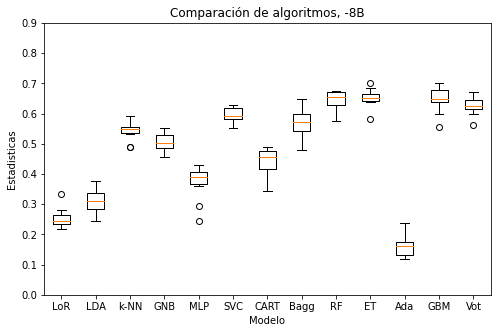

In [8]:
# boxplot algorithm comparison
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(results)
ax.set_title('Comparación de algoritmos, -8B')
ax.set_xticklabels(names)
ax.set_xlabel('Modelo')
ax.set_ylabel('Estadisticas')
top = 0.9
bottom = 0
ax.set_ylim(bottom, top)
plt.show()

In [9]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier

clf1 = LogisticRegression(penalty= 'l2',C=0.8,solver='newton-cg',multi_class='auto',warm_start=True, random_state=7)
clf2 = LinearDiscriminantAnalysis(solver='svd',n_components=1,store_covariance=True)
clf3 = KNeighborsClassifier(n_neighbors= 11,weights='distance',algorithm='ball_tree')
clf4 = GaussianNB(priors=None)
clf5 = MLPClassifier(hidden_layer_sizes= 100,activation='tanh',solver='adam',alpha=1,learning_rate='constant', random_state=7)
clf6 = SVC(C=1,kernel='rbf',degree=3, gamma=0.001,shrinking=True,probability=True, decision_function_shape='ovo',random_state=7)
clf7 = DecisionTreeClassifier(criterion='gini',splitter='best',max_features= None,max_depth=5,class_weight= None, random_state=7)
clf8 = BaggingClassifier(base_estimator=DecisionTreeClassifier(),n_estimators= 200,max_features=3, random_state=7)
clf9 = RandomForestClassifier(n_estimators=50,criterion='gini',max_depth=10,max_features='sqrt',warm_start=True, class_weight=None, random_state=7)
clf10 = ExtraTreesClassifier(n_estimators= 100,criterion='gini',max_depth= None,min_samples_leaf=2,max_features= 'log2',max_leaf_nodes=None,warm_start=True,class_weight=None,random_state=7)
clf11 = AdaBoostClassifier(base_estimator=DecisionTreeClassifier(),n_estimators=100,algorithm= 'SAMME.R',learning_rate=2.0, random_state=7)
clf12 = GradientBoostingClassifier(loss='deviance',learning_rate=0.01,n_estimators= 50,criterion='friedman_mse',max_depth=7,max_features='sqrt', random_state=7)
# Compare Algorithms
# prepare models
models = []
models.append(('LoR', LogisticRegression(penalty= 'l2',C=0.8,solver='newton-cg',multi_class='auto',warm_start=True, random_state=7)))
models.append(('LDA', LinearDiscriminantAnalysis(solver='svd',n_components=1,store_covariance=True)))
models.append(('k-NN', KNeighborsClassifier(n_neighbors= 11,weights='distance',algorithm='ball_tree')))
models.append(('GNB', GaussianNB(priors=None)))
models.append(('MLP', MLPClassifier(hidden_layer_sizes= 100,activation='tanh',solver='adam',alpha=1,learning_rate='constant', random_state=7)))
models.append(('SVC', SVC(C=1,kernel='rbf',degree=3, gamma=0.001,shrinking=True,probability=True, decision_function_shape='ovo',random_state=7)))
models.append(('CART', DecisionTreeClassifier(criterion='gini',splitter='best',max_features= None,max_depth=5,class_weight= None, random_state=7)))
models.append(('Bagg', BaggingClassifier(base_estimator=DecisionTreeClassifier(),n_estimators= 200,max_features=3, random_state=7)))
models.append(('RF', RandomForestClassifier(n_estimators=50,criterion='gini',max_depth=10,max_features='sqrt',warm_start=True, class_weight=None, random_state=7)))
models.append(('ET', ExtraTreesClassifier(n_estimators= 100,criterion='gini',max_depth= None,min_samples_leaf=2,max_features= 'log2',max_leaf_nodes=None,warm_start=True,class_weight=None,random_state=7)))
models.append(('Ada', AdaBoostClassifier(base_estimator=DecisionTreeClassifier(),n_estimators=100,algorithm= 'SAMME.R',learning_rate=2.0)))
models.append(('GBM', GradientBoostingClassifier(loss='deviance',learning_rate=0.01,n_estimators= 50,criterion='friedman_mse',max_depth=7,max_features='sqrt', random_state=7)))
models.append(('Vot', VotingClassifier(estimators=[('lor', clf1),('lda', clf2),('knn', clf3),('gnb', clf4),('mlp', clf5),('svc', clf6),
                                                      ('cart', clf7),('baf', clf8),('rf', clf9),('rt', clf10),('ada', clf11), ('gbm', clf12)], voting='hard', flatten_transform=False)))

# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
    kfold = KFold(n_splits=10, random_state=7, shuffle=True)
    cv_results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean()*100.0:,.2f}% {100-cv_results.mean()*100.0:,.2f}% ({cv_results.std()*100.0:,.2f}%)")

LoR: 32.05% 67.95% (4.27%)
LDA: 31.00% 69.00% (3.81%)
k-NN: 57.38% 42.62% (4.03%)
GNB: 50.62% 49.38% (3.13%)


C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multi

MLP: 45.19% 54.81% (2.21%)
SVC: 56.43% 43.57% (3.34%)
CART: 32.62% 67.38% (4.06%)
Bagg: 64.71% 35.29% (3.34%)
RF: 63.24% 36.76% (2.98%)
ET: 64.43% 35.57% (2.92%)
Ada: 44.86% 55.14% (4.95%)
GBM: 64.38% 35.62% (2.58%)


C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\bea-j\anaconda3\lib\site-packages\sklearn\neural_network\_multi

Vot: 62.57% 37.43% (2.73%)


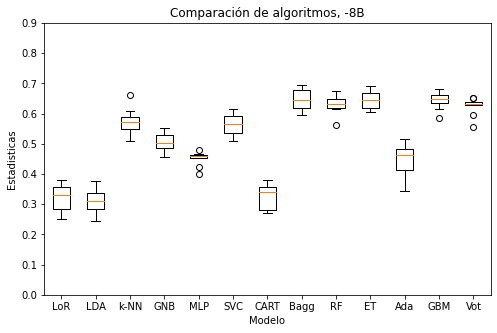

In [10]:
# boxplot algorithm comparison
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(results)
ax.set_title('Comparación de algoritmos, -8B')
ax.set_xticklabels(names)
ax.set_xlabel('Modelo')
ax.set_ylabel('Estadisticas')
top = 0.9
bottom = 0
ax.set_ylim(bottom, top)
plt.show()